In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/heart-disease/heart_disease_uci.csv


# Heart Disease Prediction – Machine Learning Project

## Objective
The goal of this project is to predict whether a patient has heart disease
based on clinical features such as age, cholesterol level, blood pressure,
and heart rate.

This is a **binary classification problem** using supervised learning.

## Dataset
We use the UCI Heart Disease dataset, a widely used dataset for
medical classification tasks.


In [1]:
import numpy as np
import pandas as pd 
import matplotlib as plt
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data=pd.read_csv("/kaggle/input/heart-disease/heart_disease_uci.csv")
data.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [3]:
list(data.columns)

['id',
 'age',
 'sex',
 'dataset',
 'cp',
 'trestbps',
 'chol',
 'fbs',
 'restecg',
 'thalch',
 'exang',
 'oldpeak',
 'slope',
 'ca',
 'thal',
 'num']

In [4]:
numeric_cols = data.select_dtypes(include=['int64', 'float64']).columns
print(numeric_cols)


Index(['id', 'age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'num'], dtype='object')


In [5]:
data.shape

(920, 16)

In [6]:
data.isna().sum()/len(data)*100

id           0.000000
age          0.000000
sex          0.000000
dataset      0.000000
cp           0.000000
trestbps     6.413043
chol         3.260870
fbs          9.782609
restecg      0.217391
thalch       5.978261
exang        5.978261
oldpeak      6.739130
slope       33.586957
ca          66.413043
thal        52.826087
num          0.000000
dtype: float64

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [8]:
column=["id","thal","ca","dataset"]
data=data.drop(columns=column)


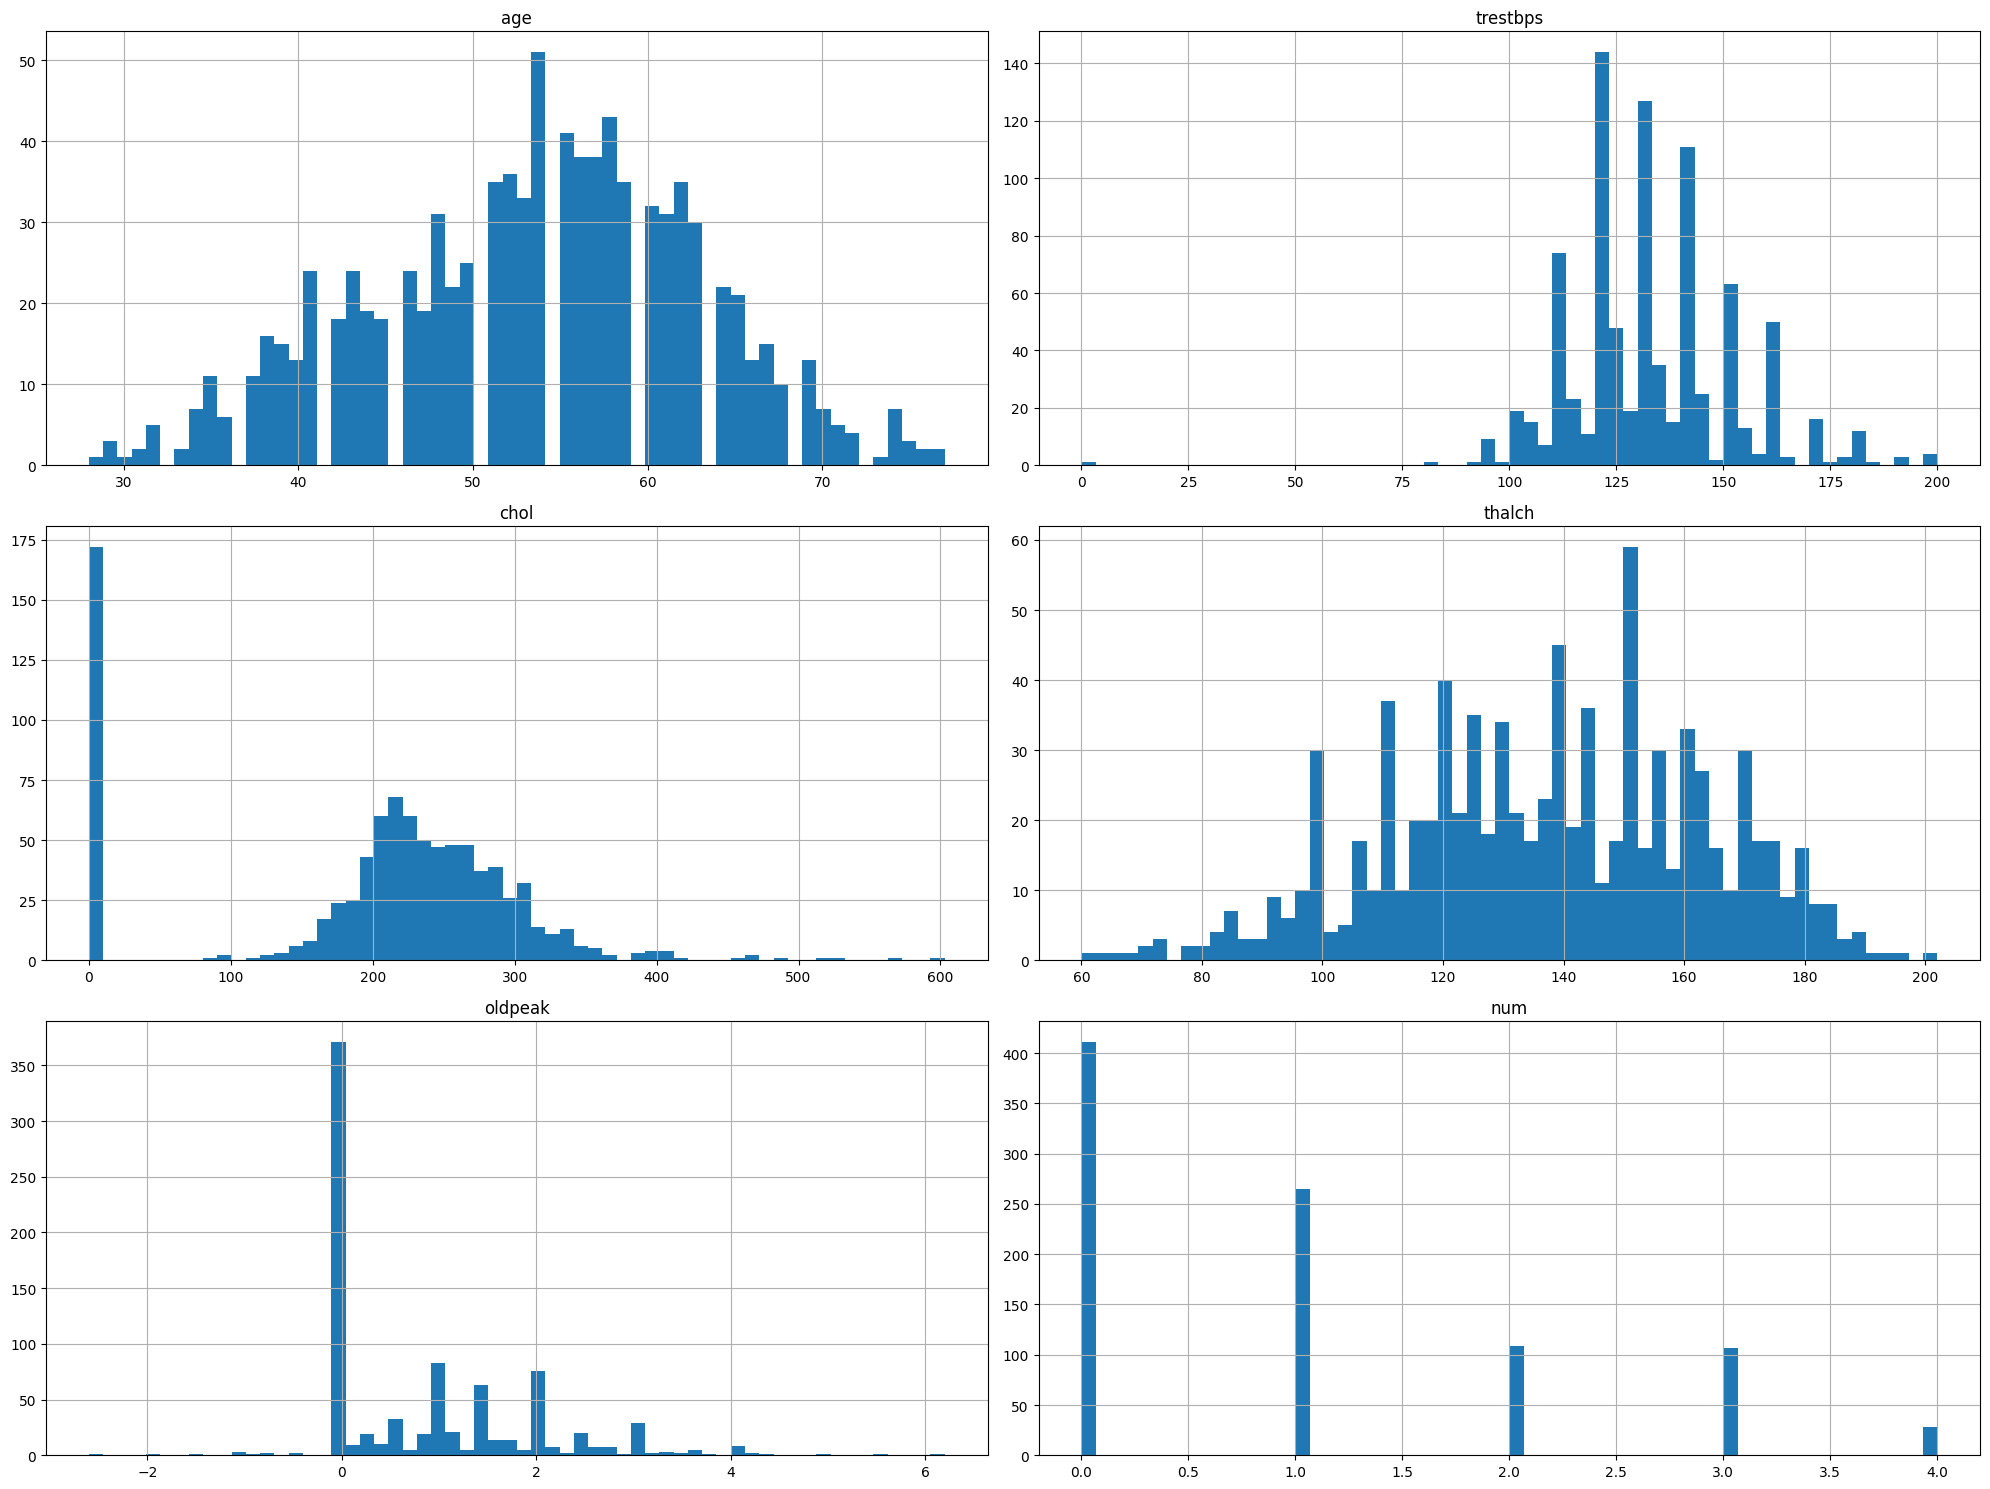

In [9]:
data.hist(bins=60, figsize=(20, 15))  # width=20 inches, height=15 inches
plt.tight_layout()  # avoid overlapping plots
plt.show()

In [10]:
median_chol=data["chol"].median()
data["chol"]=data["chol"].replace(0,median_chol)
data["chol"]=data["chol"].fillna(median_chol)
data["trestbps"]=data["trestbps"].fillna(data["trestbps"].median())
    

In [11]:
# Find rows with negative oldpeak
neg_oldpeak = data[data['oldpeak'] < 0]["oldpeak"]
print(neg_oldpeak)


603   -1.1
609   -1.5
614   -0.1
615   -2.6
629   -0.7
653   -2.0
655   -1.0
656   -1.0
691   -0.8
694   -0.5
696   -0.9
725   -0.5
Name: oldpeak, dtype: float64


In [12]:
median_oldpeak = data[data['oldpeak'] >= 0]['oldpeak'].median()
data['oldpeak'] = data['oldpeak'].apply(lambda x: median_oldpeak if x < 0 else x)
data['oldpeak'] = data['oldpeak'].fillna(data['oldpeak'].median())
data['thalch'] = data['thalch'].fillna(data['thalch'].mean())

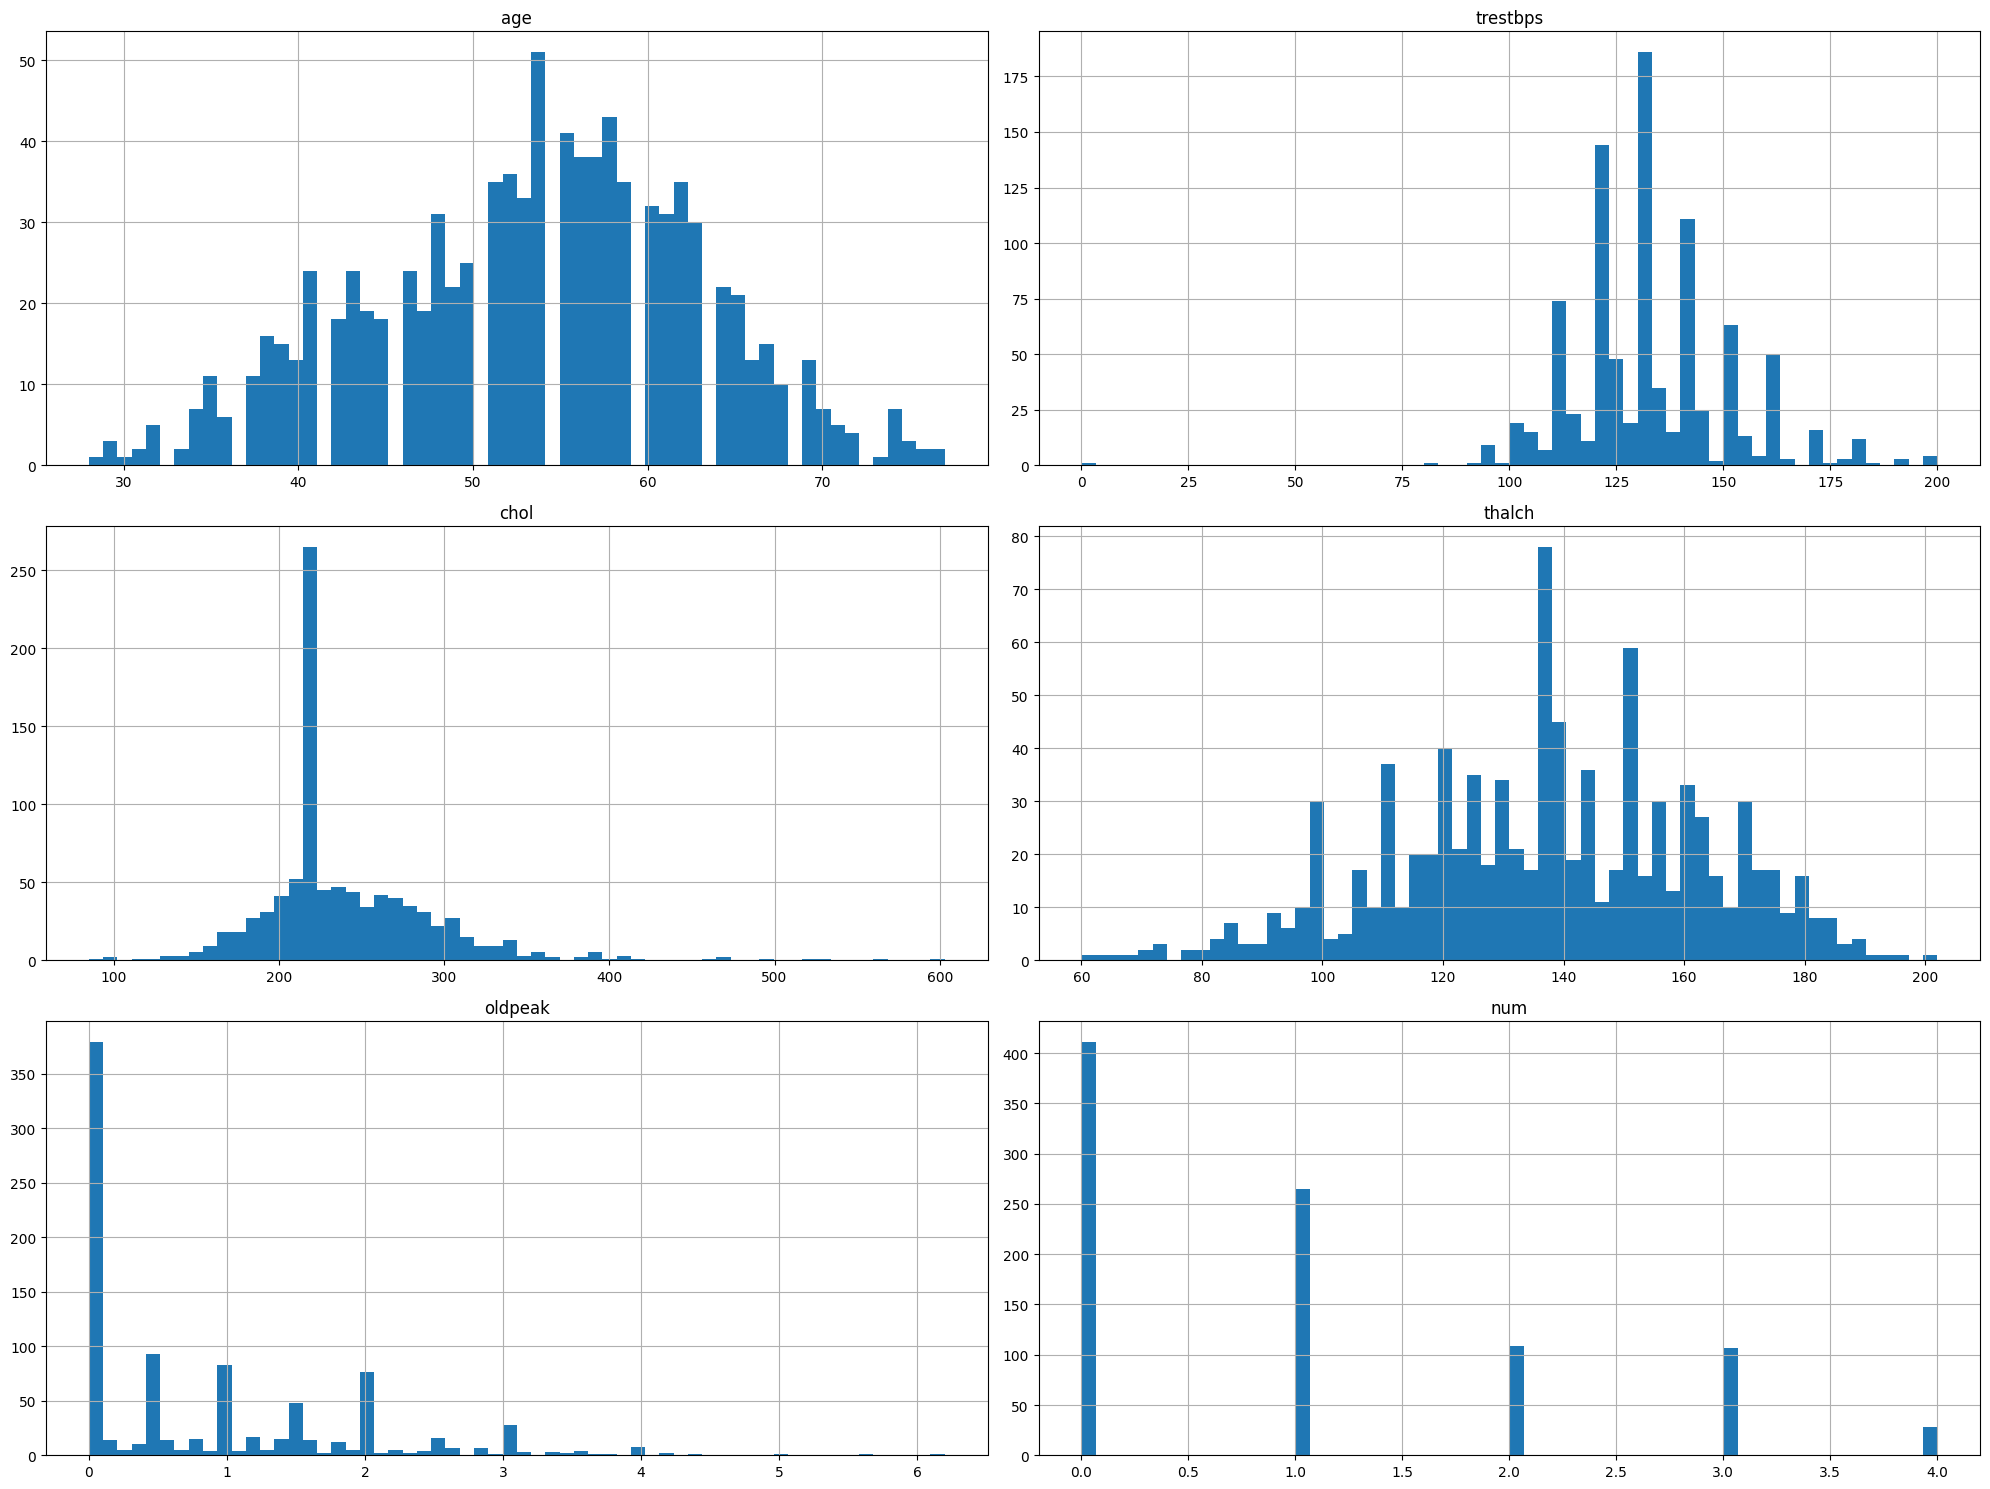

In [13]:
data.hist(bins=60, figsize=(20, 15))  # width=20 inches, height=15 inches
plt.tight_layout()  # avoid overlapping plots
plt.show()

In [14]:
categorical_columns = data.select_dtypes(include='object').columns.tolist()
print(categorical_columns)


['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope']


In [15]:
for col in categorical_columns:
    data[col]=data[col].fillna(data[col].mode()[0])

/tmp/ipykernel_55/1477886555.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data[col]=data[col].fillna(data[col].mode()[0])


In [16]:
data.isna().sum()/len(data)*100

age         0.0
sex         0.0
cp          0.0
trestbps    0.0
chol        0.0
fbs         0.0
restecg     0.0
thalch      0.0
exang       0.0
oldpeak     0.0
slope       0.0
num         0.0
dtype: float64

In [17]:
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,num
0,63,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0
1,67,Male,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,2
2,67,Male,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,1
3,37,Male,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0
4,41,Female,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0


In [18]:
data["num"] = data["num"].map({0: 0, 1: 1, 2: 1, 3: 1, 4: 1})
data["num"].value_counts()


num
1    509
0    411
Name: count, dtype: int64

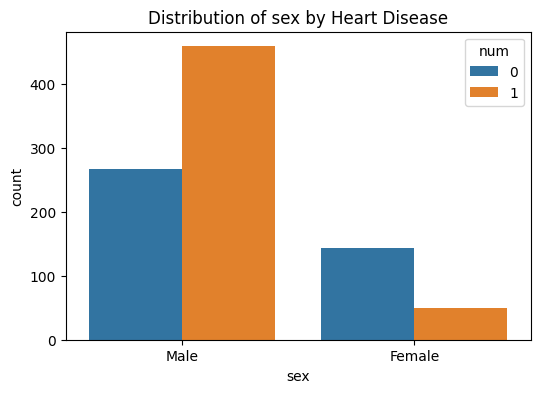

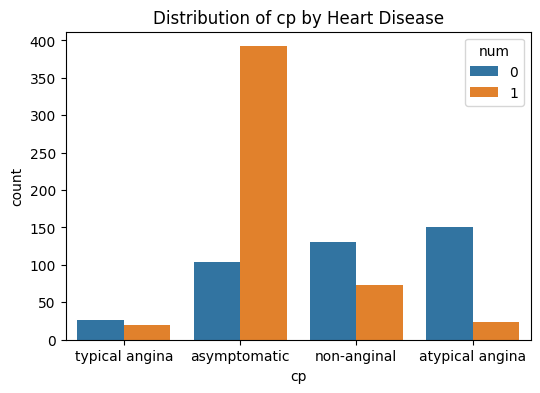

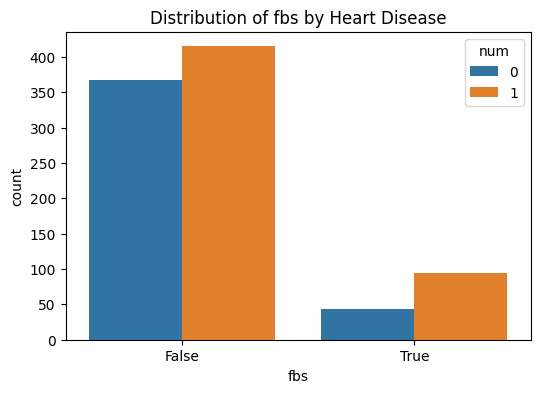

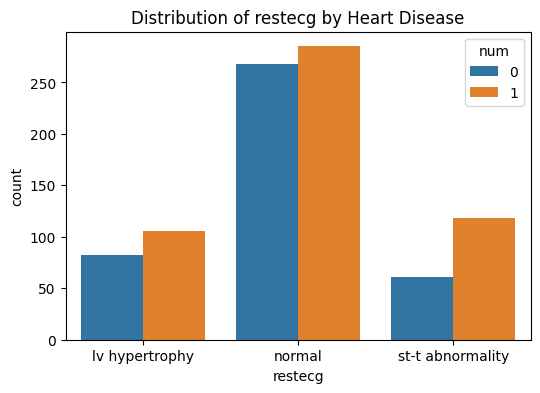

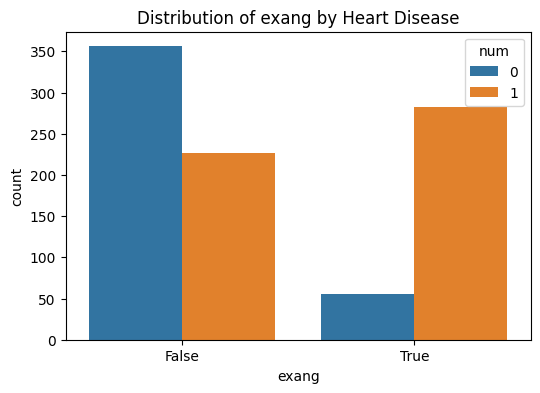

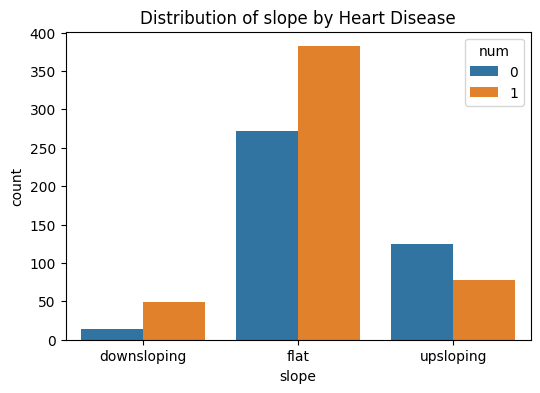

In [19]:
for col in categorical_columns:
    plt.figure(figsize=(6,4))
    sns.countplot(x=data[col], hue=data['num'])
    plt.title(f'Distribution of {col} by Heart Disease')
    plt.show()

In [20]:
data = pd.get_dummies(data, columns=categorical_columns, drop_first=True)
data.head()

,age,trestbps,chol,thalch,oldpeak,num,sex_Male,cp_atypical angina,cp_non-anginal,cp_typical angina,fbs_True,restecg_normal,restecg_st-t abnormality,exang_True,slope_flat,slope_upsloping
0,63,145.0,233.0,150.0,2.3,0,True,False,False,True,True,False,False,False,False,False
1,67,160.0,286.0,108.0,1.5,1,True,False,False,False,False,False,False,True,True,False
2,67,120.0,229.0,129.0,2.6,1,True,False,False,False,False,False,False,True,True,False
3,37,130.0,250.0,187.0,3.5,0,True,False,True,False,False,True,False,False,False,False
4,41,130.0,204.0,172.0,1.4,0,False,True,False,False,False,False,False,False,False,True


In [21]:
data["num"] = data["num"].map({0: 0, 1: 1, 2: 1, 3: 1, 4: 1})
data["num"].value_counts()

num
1    509
0    411
Name: count, dtype: int64

In [22]:
data.groupby('sex_Male')['num'].value_counts(normalize=True)


sex_Male  num
False     0      0.742268
          1      0.257732
True      1      0.632231
          0      0.367769
Name: proportion, dtype: float64

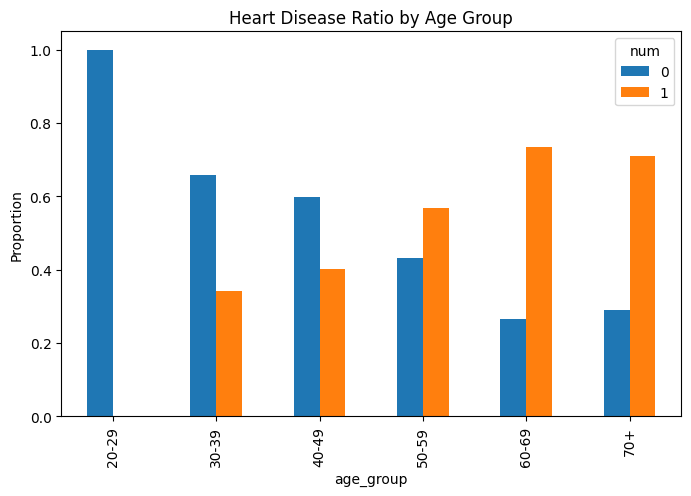

In [23]:


bins = [20, 30, 40, 50, 60, 70, 80]
labels = ['20-29', '30-39', '40-49', '50-59', '60-69', '70+']

data['age_group'] = pd.cut(data['age'], bins=bins, labels=labels, right=False)
age_target_ratio = pd.crosstab(data['age_group'], data['num'], normalize='index')
age_target_ratio.plot(kind='bar', figsize=(8,5))
plt.title('Heart Disease Ratio by Age Group')
plt.ylabel('Proportion')
plt.show()


In [24]:
data["age_over50"]=(data["age"]>=50).astype(int)
data["chol_high"]=(data["chol"]>240).astype(int)
data['old_angina_risk']=(data["age_over50"]==1)&(data["exang_True"]==1).astype(int)

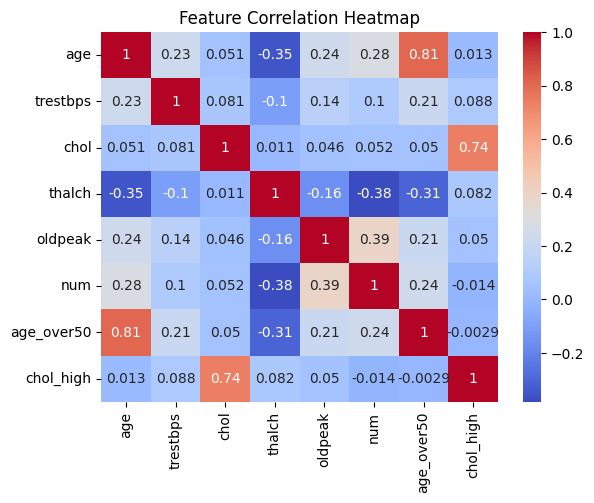

In [25]:
correlation_matrix=data.select_dtypes(include=["int","float"]).corr()
sns.heatmap(correlation_matrix,annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

In [28]:
data.drop("age_group",axis=1,inplace=True, errors='ignore')
X=data.drop("num",axis=1)
Y=data["num"]
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42,stratify=Y)
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [29]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,recall_score,confusion_matrix,classification_report
# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, Y_train)

# Prédiction
Y_pred_rf = rf.predict(X_test)

# Évaluation
print("=== Random Forest ===")
print("Accuracy:", accuracy_score(Y_test, Y_pred_rf))
print("Recall:", recall_score(Y_test, Y_pred_rf))
print(classification_report(Y_test, Y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(Y_test, Y_pred_rf))

=== Random Forest ===
Accuracy: 0.8152173913043478
Recall: 0.8627450980392157
              precision    recall  f1-score   support

           0       0.82      0.76      0.78        82
           1       0.81      0.86      0.84       102

    accuracy                           0.82       184
   macro avg       0.82      0.81      0.81       184
weighted avg       0.82      0.82      0.81       184

Confusion Matrix:
 [[62 20]
 [14 88]]


In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create the Logistic Regression model
logreg = LogisticRegression(max_iter=1000, random_state=42)

# Train the model
logreg.fit(X_train_scaled, Y_train)

# Predict on test set
Y_pred_logreg = logreg.predict(X_test_scaled)

# Evaluate
accuracy = accuracy_score(Y_test, Y_pred_logreg)
recall = classification_report(Y_test, Y_pred_logreg, output_dict=True)['1']['recall']  # recall for positive class

print(f"Logistic Regression Accuracy: {accuracy:.4f}")
print(f"Logistic Regression Recall: {recall:.4f}")
print("\nClassification Report:\n", classification_report(Y_test, Y_pred_logreg))
print("Confusion Matrix:\n", confusion_matrix(Y_test, Y_pred_logreg))


Logistic Regression Accuracy: 0.7989
Logistic Regression Recall: 0.8529

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.73      0.76        82
           1       0.80      0.85      0.82       102

    accuracy                           0.80       184
   macro avg       0.80      0.79      0.79       184
weighted avg       0.80      0.80      0.80       184

Confusion Matrix:
 [[60 22]
 [15 87]]


In [31]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create KNN model
knn = KNeighborsClassifier(n_neighbors=18)  # start with k=5
knn.fit(X_train_scaled, Y_train)

# Predict
Y_pred_knn = knn.predict(X_test_scaled)

# Evaluate
accuracy = accuracy_score(Y_test, Y_pred_knn)
recall = classification_report(Y_test, Y_pred_knn, output_dict=True)['1']['recall']  # recall for positive class

print(f"KNN Accuracy: {accuracy:.4f}")
print(f"KNN Recall: {recall:.4f}")

print("\nClassification Report:\n", classification_report(Y_test, Y_pred_knn))
print("Confusion Matrix:\n", confusion_matrix(Y_test, Y_pred_knn))


KNN Accuracy: 0.8261
KNN Recall: 0.9020

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.73      0.79        82
           1       0.81      0.90      0.85       102

    accuracy                           0.83       184
   macro avg       0.83      0.82      0.82       184
weighted avg       0.83      0.83      0.82       184

Confusion Matrix:
 [[60 22]
 [10 92]]


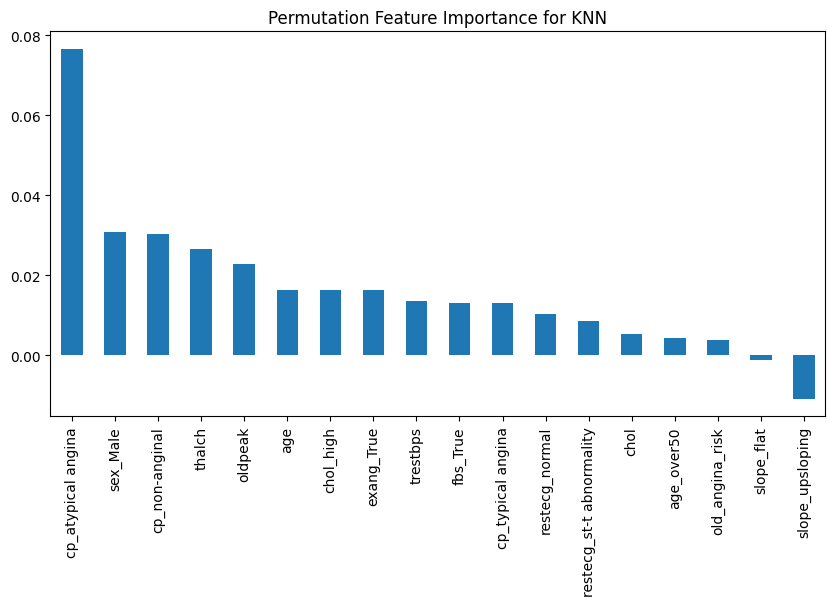

In [32]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import pandas as pd

# Compute permutation importance on test set
result = permutation_importance(
    knn, 
    X_test_scaled, 
    Y_test, 
    n_repeats=10,  # repeat to reduce noise
    random_state=42,
    scoring='accuracy'  
)

# Create a pandas Series for plotting
feat_importances = pd.Series(result.importances_mean, index=X_train.columns)
feat_importances.sort_values(ascending=False).plot(kind='bar', figsize=(10,5))
plt.title("Permutation Feature Importance for KNN")
plt.show()


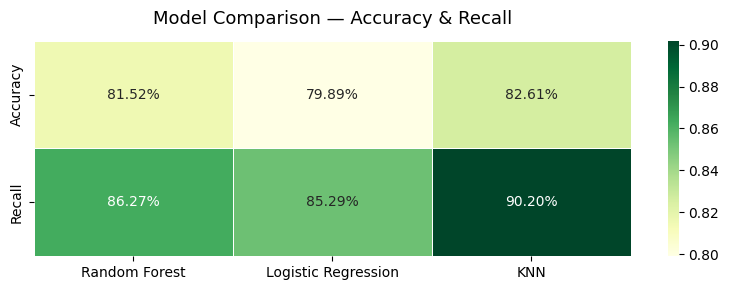

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

# ---- Résumé des performances ----
models = ['Random Forest', 'Logistic Regression', 'KNN']
accuracies = [
    accuracy_score(Y_test, Y_pred_rf),
    accuracy_score(Y_test, Y_pred_logreg),
    accuracy_score(Y_test, Y_pred_knn)
]
recalls = [
    recall_score(Y_test, Y_pred_rf),
    recall_score(Y_test, Y_pred_logreg),
    recall_score(Y_test, Y_pred_knn)
]

# ---- Heatmap de comparaison ----
metrics_data = np.array([accuracies, recalls])
fig, ax = plt.subplots(figsize=(8, 3))
sns.heatmap(
    metrics_data,
    annot=True,
    fmt=".2%",
    cmap="YlGn",
    xticklabels=models,
    yticklabels=["Accuracy", "Recall"],
    linewidths=0.5,
    ax=ax
)
ax.set_title("Model Comparison — Accuracy & Recall", fontsize=13, pad=12)
plt.tight_layout()
plt.savefig("model_comparison_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()
